# Context Influence on Language Model Predictions — Book Comparison

## Comparing *The Diary of Anne Frank* vs. *Becoming* by Michelle Obama

**Purpose:** This notebook measures how context influences GPT-2's predictions on text
extracted from two books with very different registers and styles.

### What This Notebook Does

Given sentences from each book, this notebook:

1. **Measures token-level and word-level entropy/surprisal**
2. **Measures perplexity**
3. **Runs context ablation** at random positions to see how much preceding material the model uses.
4. **Compares conditions** using independent Welch's t-tests and Mann-Whitney U.

### Key Concepts

- **Entropy** (bits): Model uncertainty. High = uncertain, low = confident.
- **Surprisal** (bits): How surprised is the model by the actual next word?
- **Perplexity**: Exponential of average surprisal.
- **Context ablation**: Feed the model only the last k words before a position.


---
## 0. Setup and Installation

Run this cell first. Installs PyMuPDF for PDF extraction plus all other dependencies.


In [1]:
# ============================================================================
# INSTALL DEPENDENCIES (uncomment if needed)
# ============================================================================
# !pip install torch transformers numpy pandas scipy matplotlib seaborn tqdm PyMuPDF

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import AutoModelForCausalLM, AutoTokenizer
from typing import Dict, List, Set, Tuple, Optional
from collections import defaultdict
from tqdm.auto import tqdm
import json
import re
import fitz  # PyMuPDF for PDF extraction
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# --------------------------------------------------------------------------
# AUTO-DETECT GPU
# --------------------------------------------------------------------------
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using Apple MPS (Metal). If you hit errors, switch to CPU.')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU (slower but always works)')

print(f'Device: {DEVICE}')


Using CPU (slower but always works)
Device: cpu


---
## 1. Load a Language Model

We use HuggingFace's `transformers` library to load any **causal (autoregressive) language model**.
These models predict the next token given preceding context — exactly what we need.

### Choosing a Model

| Model | Parameters | Speed | Notes |
|-------|-----------|-------|-------|
| `gpt2` | 124M | Fast | Good default for exploration |
| `gpt2-medium` | 355M | Medium | Better predictions |
| `gpt2-large` | 774M | Slow | Even better, needs more RAM |
| `gpt2-xl` | 1.5B | Very slow | Best GPT-2, needs GPU |
| `EleutherAI/pythia-160m` | 160M | Fast | Alternative architecture |
| `EleutherAI/pythia-410m` | 410M | Medium | Good Pythia variant |
| `EleutherAI/pythia-1b` | 1B | Slow | Larger Pythia |

**Tip:** Start with `gpt2` for fast iteration. Scale up once your pipeline works.

In [2]:
# ============================================================================
# CONFIGURATION — CHANGE THIS TO USE A DIFFERENT MODEL
# ============================================================================
MODEL_NAME = 'gpt2'  # <-- Change this to try other models

# --------------------------------------------------------------------------
# Load tokenizer and model
# --------------------------------------------------------------------------
# The tokenizer converts text to token IDs and back.
# The model takes token IDs and outputs logits (unnormalized probabilities)
# for what the next token should be at each position.
# --------------------------------------------------------------------------
print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# Put model on GPU/CPU and set to evaluation mode
# eval() disables dropout — important for reproducible results!
model = model.to(DEVICE)
model.eval()

print(f"Loaded {MODEL_NAME} ({sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters)")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")

Loading gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded gpt2 (124M parameters)
Vocabulary size: 50,257 tokens


---
## 2. Core Metric Functions

These are the building blocks. Each function computes one type of measurement.
You'll call these from the higher-level analysis functions in later sections.

In [3]:
# ============================================================================
# CORE METRIC: ENTROPY AND SURPRISAL
# ============================================================================
#
# Given the model's logits (raw output) at a position, we compute:
#
#   Entropy  = -SUM( p(token) * log2(p(token)) )  for all tokens in vocabulary
#            = How uncertain is the model about what comes next?
#            = Measured in bits. Range: 0 (perfectly certain) to ~15 (totally lost)
#
#   Surprisal = -log2( p(actual_next_token) )
#             = How surprised is the model by what actually came next?
#             = Measured in bits. High = unexpected, low = expected.
#
# The 1e-10 epsilon prevents log(0) which would give -infinity.
# ============================================================================

def compute_entropy_and_surprisal(logits: torch.Tensor, actual_token_id: int) -> Tuple[float, float]:
    """
    Compute entropy of the full distribution and surprisal of the actual next token.

    Args:
        logits: Raw model output at one position, shape [vocab_size]
        actual_token_id: The token that actually appeared next in the text

    Returns:
        (entropy_bits, surprisal_bits) tuple
    """
    # Convert logits to probabilities via softmax
    # softmax(x_i) = exp(x_i) / sum(exp(x_j)) — normalizes to sum to 1
    probs = torch.softmax(logits, dim=-1)

    # Entropy: H = -sum(p * log2(p))
    log_probs = torch.log2(probs + 1e-10)
    entropy = -(probs * log_probs).sum().item()

    # Surprisal of the actual token: -log2(p(actual))
    actual_prob = probs[actual_token_id].item()
    surprisal = -np.log2(actual_prob + 1e-10)

    return entropy, surprisal


# ============================================================================
# CORE METRIC: PERPLEXITY
# ============================================================================
#
# Perplexity = exp( mean negative log-likelihood )
#            = 2^(mean surprisal)           [if using log base 2]
#
# Intuitively: if perplexity = 50, the model is "as confused as if it were
# choosing uniformly among 50 equally likely words" at each position.
#
# Lower perplexity = better predictions = the model "understands" the text.
# ============================================================================

def compute_perplexity(model, tokenizer, text: str, device=DEVICE) -> float:
    """
    Compute perplexity of a text under the model.

    Args:
        model: HuggingFace causal LM
        tokenizer: Corresponding tokenizer
        text: Input text string
        device: torch device

    Returns:
        Perplexity (float). Lower = model predicts the text better.
    """
    # Tokenize the text
    inputs = tokenizer(text, return_tensors='pt').to(device)

    with torch.no_grad():
        # labels=input_ids tells the model to compute cross-entropy loss
        # against the actual next tokens (teacher forcing)
        outputs = model(**inputs, labels=inputs['input_ids'])

    # outputs.loss is the mean negative log-likelihood (base e)
    # perplexity = exp(loss)
    return torch.exp(outputs.loss).item()

In [4]:
# ============================================================================
# WORD-ALIGNED METRICS
# ============================================================================
#
# PROBLEM: BPE tokenization splits words unpredictably.
#   "studying" -> [" study", "ing"] (2 tokens)
#   "cat"      -> [" cat"]          (1 token)
#
# If we compare entropy at the token level, multi-token words get more
# data points, biasing the comparison. Worse, nonce/nonsense words get
# split differently than real words, creating systematic artifacts.
#
# SOLUTION: Map tokens back to whitespace-delimited words using character
# offsets, then aggregate (mean or sum) each word's token-level metrics.
# ============================================================================

def process_text_full_metrics(model, tokenizer, text: str, device=DEVICE) -> Dict:
    """
    Compute comprehensive token-level AND word-level metrics for a text.

    This is the main workhorse function. For each position in the text, it:
    1. Gets the model's probability distribution over next tokens
    2. Computes entropy (model uncertainty) and surprisal (prediction error)
    3. Maps these back to word boundaries for word-level aggregation

    Args:
        model: HuggingFace causal LM
        tokenizer: Corresponding tokenizer
        text: Input text string
        device: torch device

    Returns:
        Dictionary with both token-level and word-level metrics:
        {
            'text': original text,
            'words': list of whitespace-delimited words,
            'n_tokens': number of BPE tokens,
            'n_words': number of whitespace words,
            'perplexity': overall perplexity,
            'mean_entropy': mean token-level entropy (bits),
            'mean_surprisal': mean token-level surprisal (bits),
            'token_entropies': list of per-token entropy values,
            'token_surprisals': list of per-token surprisal values,
            'word_entropies': list of per-word mean entropy,
            'word_surprisals': list of per-word mean surprisal,
            'mean_word_entropy': mean of word-level entropies,
            'mean_word_surprisal': mean of word-level surprisals,
        }
    """
    # --- Step 1: Tokenize with offset mapping ---
    # return_offsets_mapping=True gives us (start_char, end_char) for each token,
    # which we need to map tokens back to words.
    encoding = tokenizer(
        text,
        return_tensors='pt',
        return_offsets_mapping=True,
        add_special_tokens=False  # No <BOS>/<EOS> tokens — just the raw text
    )
    input_ids = encoding['input_ids'].to(device)
    offset_mapping = encoding['offset_mapping'][0].tolist()  # [(start, end), ...]

    # --- Step 2: Get model logits ---
    # logits shape: [1, seq_len, vocab_size]
    # logits[0, i, :] = unnormalized probabilities for what comes after position i
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        logits = outputs.logits

    # --- Step 3: Compute per-token entropy and surprisal ---
    # We iterate positions 0..N-2 because position i predicts token i+1.
    # (The last position has no "next token" to evaluate against.)
    token_entropies = []
    token_surprisals = []

    for i in range(input_ids.shape[1] - 1):
        next_token_logits = logits[0, i, :]       # Predictions at position i
        actual_next_token = input_ids[0, i + 1].item()  # What actually came next

        entropy, surprisal = compute_entropy_and_surprisal(next_token_logits, actual_next_token)
        token_entropies.append(entropy)
        token_surprisals.append(surprisal)

    # --- Step 4: Map tokens to words ---
    # Find word boundaries from whitespace in the original text
    words = text.split()
    word_starts = []
    word_ends = []
    pos = 0
    for w in words:
        idx = text.index(w, pos)
        word_starts.append(idx)
        word_ends.append(idx + len(w))
        pos = idx + len(w)

    # Map each token to its word based on character offset overlap
    # We use offset_mapping[:-1] because token_entropies has length N-1
    # (we lose the last token since there's no "next" to evaluate)
    word_to_token_metrics = defaultdict(lambda: {'entropies': [], 'surprisals': []})

    for tok_idx, (tok_start, tok_end) in enumerate(offset_mapping[:-1]):
        if tok_idx >= len(token_entropies):
            break
        # Find which word this token belongs to
        for w_idx in range(len(word_starts)):
            if tok_start < word_ends[w_idx] and tok_end > word_starts[w_idx]:
                word_to_token_metrics[w_idx]['entropies'].append(token_entropies[tok_idx])
                word_to_token_metrics[w_idx]['surprisals'].append(token_surprisals[tok_idx])
                break

    # --- Step 5: Aggregate to word level ---
    # For each word, take the MEAN of its constituent tokens' metrics.
    # (You could also use SUM — see notes below.)
    word_entropies = []
    word_surprisals = []
    for w_idx in range(len(words)):
        if w_idx in word_to_token_metrics and word_to_token_metrics[w_idx]['entropies']:
            word_entropies.append(np.mean(word_to_token_metrics[w_idx]['entropies']))
            word_surprisals.append(np.mean(word_to_token_metrics[w_idx]['surprisals']))
        else:
            word_entropies.append(np.nan)
            word_surprisals.append(np.nan)

    return {
        'text': text,
        'words': words,
        'n_tokens': len(token_entropies),
        'n_words': len(words),
        'perplexity': torch.exp(outputs.loss).item(),
        'mean_entropy': np.mean(token_entropies) if token_entropies else 0,
        'mean_surprisal': np.mean(token_surprisals) if token_surprisals else 0,
        'token_entropies': token_entropies,
        'token_surprisals': token_surprisals,
        'word_entropies': word_entropies,
        'word_surprisals': word_surprisals,
        'mean_word_entropy': float(np.nanmean(word_entropies)) if word_entropies else 0,
        'mean_word_surprisal': float(np.nanmean(word_surprisals)) if word_surprisals else 0,
    }

In [5]:
# ============================================================================
# (Class probability mass functions removed — not used in this analysis)
# ============================================================================
# This notebook uses random-position context ablation measuring entropy only,
# so no cue-word or class-mass machinery is needed.


---
## 3. Quick Demo: See the Metrics in Action

Before diving into corpus-level analysis, let's see what these metrics look like on a single sentence.

In [6]:
# ============================================================================
# DEMO: Single sentence analysis
# ============================================================================
demo_text = "the scientist decided to study the ancient artifacts carefully"

print(f'Text: {demo_text}')
print('=' * 70)

# --- Compute full metrics ---
metrics = process_text_full_metrics(model, tokenizer, demo_text)

print(f'\nOverall:')
print(f'  Perplexity:      {metrics["perplexity"]:.2f}')
print(f'  Mean entropy:    {metrics["mean_word_entropy"]:.2f} bits (word-level)')
print(f'  Mean surprisal:  {metrics["mean_word_surprisal"]:.2f} bits (word-level)')
print(f'  Tokens: {metrics["n_tokens"]}  |  Words: {metrics["n_words"]}')

print(f'\nPer-word breakdown:')
print(f'  {"Word":<15} {"Entropy":>10} {"Surprisal":>10}')
print(f'  {"-"*35}')
for word, ent, surp in zip(metrics['words'], metrics['word_entropies'], metrics['word_surprisals']):
    print(f'  {word:<15} {ent:>10.2f} {surp:>10.2f}')


Text: the scientist decided to study the ancient artifacts carefully


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Overall:
  Perplexity:      302.20
  Mean entropy:    8.07 bits (word-level)
  Mean surprisal:  8.24 bits (word-level)
  Tokens: 8  |  Words: 9

Per-word breakdown:
  Word               Entropy  Surprisal
  -----------------------------------
  the                  12.73      15.21
  scientist             7.49      11.66
  decided               2.62       0.68
  to                    8.07       6.40
  study                 6.60       1.50
  the                  10.62       9.98
  ancient              10.66       9.54
  artifacts             5.73      10.95
  carefully              nan        nan


---
## 4. Context Ablation: How Much Context Does the Model Use?

We systematically **truncate** the context before a target position and measure how predictions change.

### How it works:
1. For each sentence, pick 3 random word positions (excluding first and last word)
2. Feed the model only the last k=1, 2, 4, 8, 16 words as context
3. Measure entropy at each k
4. Plot entropy vs. context length


In [7]:
# ============================================================================
# CONTEXT ABLATION: Measure influence of context length on predictions
# ============================================================================

def context_ablation(
    model, tokenizer,
    text: str,
    target_word_index: int,
    context_sizes: List[int] = None,
    device=DEVICE
) -> pd.DataFrame:
    """
    Measure how entropy changes as we vary context length before a target position.

    Args:
        model: Language model
        tokenizer: Tokenizer
        text: Full text
        target_word_index: Index of the word we are predicting AFTER.
        context_sizes: List of context sizes (in words) to test.
        device: torch device

    Returns:
        DataFrame with columns: [k, context, entropy]
    """
    words = text.split()

    if target_word_index >= len(words):
        raise ValueError(f"target_word_index {target_word_index} >= number of words {len(words)}")

    # Words up to and including the target position
    full_prefix_words = words[:target_word_index + 1]
    full_k = len(full_prefix_words)

    if context_sizes is None:
        context_sizes = [1, 2, 4, 8, 16]

    results = []

    for k in context_sizes:
        if k > full_k:
            continue

        # Take last k words as context
        context_words = full_prefix_words[-k:]
        context = ' '.join(context_words)

        # Get model predictions after this context
        inputs = tokenizer(context, return_tensors='pt').to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits[0, -1, :]  # Last position predictions
        probs = torch.softmax(logits, dim=-1)

        # Compute entropy
        log_probs = torch.log2(probs + 1e-10)
        entropy = -(probs * log_probs).sum().item()

        row = {'k': k, 'context': context, 'entropy': entropy}
        results.append(row)

    return pd.DataFrame(results)


Sentence: the experienced scientist decided to study the ancient artifacts carefully
Chosen positions: ['experienced', 'scientist', 'the'] (indices [np.int64(1), np.int64(2), np.int64(6)])

--- Position 1: 'experienced' ---


 k   entropy
 1 11.044843
 2 11.158010

--- Position 2: 'scientist' ---


 k  entropy
 1 8.818373
 2 6.067728

--- Position 6: 'the' ---


 k   entropy
 1 12.734390
 2 11.615664
 4 10.569285



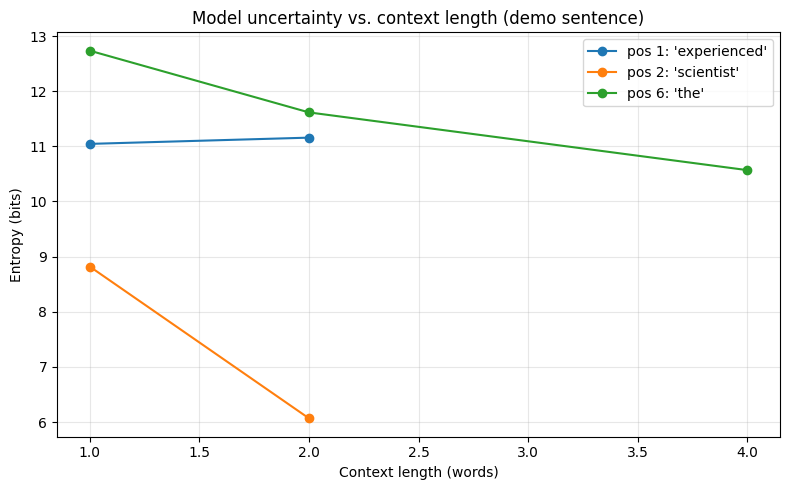


Interpretation:
- If entropy DROPS as k increases: more context helps the model predict.
- Flat curves = the model does not use that extra context.


In [8]:
# ============================================================================
# DEMO: Context ablation on a single sentence (random positions, entropy only)
# ============================================================================
demo_text = "the experienced scientist decided to study the ancient artifacts carefully"
words = demo_text.split()

CONTEXT_SIZES = [1, 2, 4, 8, 16]

# Pick 3 random positions (excluding first and last word)
eligible = list(range(1, len(words) - 1))
chosen_positions = np.random.choice(eligible, size=min(3, len(eligible)), replace=False)
chosen_positions.sort()

print(f'Sentence: {demo_text}')
print(f'Chosen positions: {[words[p] for p in chosen_positions]} (indices {list(chosen_positions)})')
print()

all_demo_ablation = []

for pos in chosen_positions:
    print(f'--- Position {pos}: {words[pos]!r} ---')
    abl_df = context_ablation(
        model, tokenizer, demo_text,
        target_word_index=pos,
        context_sizes=CONTEXT_SIZES
    )
    abl_df['position'] = pos
    abl_df['target_word'] = words[pos]
    all_demo_ablation.append(abl_df)
    print(abl_df[['k', 'entropy']].to_string(index=False))
    print()

demo_ablation_df = pd.concat(all_demo_ablation, ignore_index=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

for pos in chosen_positions:
    subset = demo_ablation_df[demo_ablation_df['position'] == pos]
    ax.plot(subset['k'], subset['entropy'], 'o-', label=f'pos {pos}: {words[pos]!r}')

ax.set_xlabel('Context length (words)')
ax.set_ylabel('Entropy (bits)')
ax.set_title('Model uncertainty vs. context length (demo sentence)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- If entropy DROPS as k increases: more context helps the model predict.')
print('- Flat curves = the model does not use that extra context.')


---
## 5. Corpus-Level Analysis

Now the real work: extracting text from PDFs and running measurements.

### PDF Processing Pipeline:
1. Extract raw text from each PDF using PyMuPDF
2. Clean out page numbers, headers, footers, TOC, copyright, acknowledgments
3. Split into sentences and filter out sentences shorter than 4 words
4. **Length-match**: group sentences by word count; for each word count present in both books,
   randomly sample an equal number from each (the minimum available in either book)
5. Cap at 500 sentences per condition (randomly downsampled if needed, preserving length balance)


In [9]:
# ============================================================================
# LOAD AND CLEAN PDF CORPUS
# ============================================================================

def extract_text_from_pdf(filepath: str) -> str:
    """Extract all text from a PDF using PyMuPDF."""
    doc = fitz.open(filepath)
    pages = []
    for page in doc:
        pages.append(page.get_text())
    doc.close()
    return '\n'.join(pages)


def clean_book_text(raw_text: str) -> str:
    """
    Clean extracted PDF text by removing non-body content:
    page numbers, headers/footers, TOC, copyright, acknowledgments, etc.
    """
    lines = raw_text.split('\n')
    cleaned_lines = []
    skip_section = False

    for line in lines:
        stripped = line.strip()

        # Skip empty lines
        if not stripped:
            continue

        # Skip URLs
        if re.match(r'^https?://', stripped, re.IGNORECASE):
            continue

        # Skip standalone page numbers
        if re.match(r'^\d{1,4}$', stripped):
            continue

        # Skip common headers/footers patterns
        if re.match(r'^(page\s+)?\d+\s*$', stripped, re.IGNORECASE):
            continue

        # Skip table of contents markers
        if re.match(r'^(table of contents|contents)$', stripped, re.IGNORECASE):
            skip_section = True
            continue

        # Skip copyright/legal pages
        if re.match(r'^(copyright|all rights reserved|isbn|library of congress|published by|first edition|printed in)', stripped, re.IGNORECASE):
            skip_section = True
            continue

        # Skip acknowledgments/dedication/back-matter sections
        if re.match(r'^(acknowledgments?|dedication|about the author|also by|author.s note|editor.s note|translator.s note|afterword|appendix|notes|bibliography|index|glossary|photograph credits|photograph insert|endpaper photographs)$', stripped, re.IGNORECASE):
            skip_section = True
            continue

        # Reset skip flag on chapter headings, part headings, numbered sections,
        # date headings (for diaries like Anne Frank), or 'FOREWORD'/'PROLOGUE' etc.
        if re.match(r'^(chapter\s+\w+|part\s+\w+|\d+\.|foreword|prologue|preface|introduction)', stripped, re.IGNORECASE):
            skip_section = False
        # Also reset on diary-style date headings: "SUNDAY, JUNE 14, 1942" or "June 12, 1942"
        if re.match(r'^(monday|tuesday|wednesday|thursday|friday|saturday|sunday|january|february|march|april|may|june|july|august|september|october|november|december)', stripped, re.IGNORECASE):
            skip_section = False

        # Skip TOC entries (text followed by dots and page number)
        if re.match(r'^.+\.{3,}\s*\d+$', stripped):
            continue

        # Skip lines that are ONLY date headings (no body text)
        if re.match(r'^(MONDAY|TUESDAY|WEDNESDAY|THURSDAY|FRIDAY|SATURDAY|SUNDAY),\s+(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)\s+\d{1,2},\s*\d{4}$', stripped, re.IGNORECASE):
            continue

        # Skip standalone day-of-week date lines used as headings in TOC
        if re.match(r'^\w+day(\s+\w+)?,\s+\w+\s+\d{1,2},?\s*\d{4}$', stripped, re.IGNORECASE):
            continue

        # Skip editorial comments (Anne Frank diary annotations)
        if re.match(r'^COMMENT ADDED BY ANNE', stripped):
            continue

        # Skip very short lines (likely headers/footers)
        if len(stripped) < 3:
            continue

        if not skip_section:
            cleaned_lines.append(stripped)

    return ' '.join(cleaned_lines)


def split_into_sentences(text: str) -> List[str]:
    """Split text into sentences using regex."""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    cleaned = []
    for s in sentences:
        s = s.strip()
        s = re.sub(r'\s+', ' ', s)  # Normalize whitespace
        if s:
            cleaned.append(s)
    return cleaned


# --- Extract and process both PDFs ---
print('Extracting text from PDFs...')

raw_anne = extract_text_from_pdf('Anne Frank.pdf')
raw_michelle = extract_text_from_pdf('Becoming Michelle.pdf')

print(f'  Anne Frank raw: {len(raw_anne):,} characters')
print(f'  Becoming Michelle raw: {len(raw_michelle):,} characters')

# Clean the text
clean_anne = clean_book_text(raw_anne)
clean_michelle = clean_book_text(raw_michelle)

print(f'  Anne Frank cleaned: {len(clean_anne):,} characters')
print(f'  Becoming Michelle cleaned: {len(clean_michelle):,} characters')

# Split into sentences
sentences_anne = split_into_sentences(clean_anne)
sentences_michelle = split_into_sentences(clean_michelle)

print(f'  Anne Frank sentences: {len(sentences_anne):,}')
print(f'  Becoming Michelle sentences: {len(sentences_michelle):,}')

# --------------------------------------------------------------------------
# LENGTH-MATCHED SAMPLING (capped at 500 per condition)
# --------------------------------------------------------------------------
# Group sentences by word count. For each word count present in both books,
# randomly sample min(n_anne, n_michelle) from each. Then if the total per
# condition exceeds 500, randomly downsample to 500 (preserving length balance).
# --------------------------------------------------------------------------
MIN_WORDS = 4
MAX_PER_CONDITION = 500

from collections import defaultdict

anne_by_len = defaultdict(list)
for s in sentences_anne:
    wc = len(s.split())
    if wc >= MIN_WORDS:
        anne_by_len[wc].append(s)

michelle_by_len = defaultdict(list)
for s in sentences_michelle:
    wc = len(s.split())
    if wc >= MIN_WORDS:
        michelle_by_len[wc].append(s)

shared_lengths = sorted(set(anne_by_len.keys()) & set(michelle_by_len.keys()))

rng = np.random.RandomState(42)

# First pass: gather all length-matched pairs
matched_anne = []
matched_michelle = []
length_report_raw = []

for wc in shared_lengths:
    n_anne = len(anne_by_len[wc])
    n_michelle = len(michelle_by_len[wc])
    n_sample = min(n_anne, n_michelle)

    sa = list(rng.choice(anne_by_len[wc], size=n_sample, replace=False))
    sm = list(rng.choice(michelle_by_len[wc], size=n_sample, replace=False))

    for s in sa:
        matched_anne.append({'text': s, 'condition': 'anne_frank', 'word_count': wc})
    for s in sm:
        matched_michelle.append({'text': s, 'condition': 'becoming_michelle', 'word_count': wc})

    length_report_raw.append({'word_count': wc, 'matched': n_sample,
                              'available_anne': n_anne, 'available_michelle': n_michelle})

print(f'Before cap: {len(matched_anne)} matched sentences per condition')

# Second pass: if over 500, randomly downsample paired indices
if len(matched_anne) > MAX_PER_CONDITION:
    keep_idx = sorted(rng.choice(len(matched_anne), size=MAX_PER_CONDITION, replace=False))
    matched_anne = [matched_anne[i] for i in keep_idx]
    matched_michelle = [matched_michelle[i] for i in keep_idx]

corpus = matched_anne + matched_michelle

# Build final length report from what survived
from collections import Counter
final_counts = Counter(item['word_count'] for item in matched_anne)
length_report = []
for wc in sorted(final_counts.keys()):
    raw = next(r for r in length_report_raw if r['word_count'] == wc)
    length_report.append({'word_count': wc, 'n_per_condition': final_counts[wc],
                          'available_anne': raw['available_anne'],
                          'available_michelle': raw['available_michelle']})
length_df = pd.DataFrame(length_report)

print(f'\nLength-matched corpus: {len(corpus)} items '
      f'({len(matched_anne)} per condition)')
print(f'Shared word-count bins used: {len(final_counts)}')
print(f'Word-count range: {min(final_counts)}-{max(final_counts)}')
print()
print('Matched sentences per word count:')
print(length_df.to_string(index=False))

print(f'\nCondition totals:')
for cond in ['anne_frank', 'becoming_michelle']:
    n = sum(1 for item in corpus if item['condition'] == cond)
    print(f'  {cond}: {n} sentences')

# Show a few examples from each
for cond in ['anne_frank', 'becoming_michelle']:
    examples = [item for item in corpus if item['condition'] == cond][:3]
    print(f'\nExample sentences ({cond}):')
    for ex in examples:
        txt = ex['text'][:100]
        ellipsis = '...' if len(ex['text']) > 100 else ''
        print(f'  [{ex["word_count"]}w] "{txt}{ellipsis}"')


Extracting text from PDFs...


  Anne Frank raw: 559,224 characters
  Becoming Michelle raw: 920,281 characters


  Anne Frank cleaned: 547,086 characters
  Becoming Michelle cleaned: 906,580 characters


  Anne Frank sentences: 6,956
  Becoming Michelle sentences: 8,056
Before cap: 5905 matched sentences per condition

Length-matched corpus: 1000 items (500 per condition)
Shared word-count bins used: 49
Word-count range: 4-66

Matched sentences per word count:
 word_count  n_per_condition  available_anne  available_michelle
          4               18             216                 207
          5               19             243                 218
          6               10             270                 269
          7               21             276                 283
          8               22             299                 264
          9               22             313                 351
         10               22             322                 301
         11               14             288                 293
         12               31             294                 299
         13               32             317                 279
         14             

In [10]:
# ============================================================================
# RUN METRICS ON THE FULL CORPUS
# ============================================================================
# This iterates over every item in the corpus and computes all metrics.
# Results are stored in a list of dictionaries, then converted to a DataFrame.
#
# For a large corpus, this is the slow part — each item requires a forward
# pass through the model. On CPU, expect ~5-20 items/second for GPT-2.
# On GPU, expect ~50-200 items/second.
# ============================================================================

all_results = []

for item in tqdm(corpus, desc="Processing corpus"):
    text = item['text']

    # Compute all metrics for this text
    metrics = process_text_full_metrics(model, tokenizer, text)

    # Combine item metadata with computed metrics
    result = {
        **{k: v for k, v in item.items() if k != 'text'},  # Copy metadata (condition, set_id, etc.)
        'text': text,
        'perplexity': metrics['perplexity'],
        'mean_entropy': metrics['mean_entropy'],
        'mean_surprisal': metrics['mean_surprisal'],
        'mean_word_entropy': metrics['mean_word_entropy'],
        'mean_word_surprisal': metrics['mean_word_surprisal'],
        'n_tokens': metrics['n_tokens'],
        'n_words': metrics['n_words'],
    }
    all_results.append(result)

# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(all_results)

print(f"\nProcessed {len(results_df)} items.")
print(f"\nSummary by condition:")
print(results_df.groupby('condition')[[
    'perplexity', 'mean_word_entropy', 'mean_word_surprisal'
]].mean().round(2).to_string())

Processing corpus:   0%|          | 0/1000 [00:00<?, ?it/s]


Processed 1000 items.

Summary by condition:
                   perplexity  mean_word_entropy  mean_word_surprisal
condition                                                            
anne_frank             126.70               6.32                 6.13
becoming_michelle      123.46               6.29                 6.14


---
## 6. Statistical Comparison Between Conditions

Since the sentences from each book are independent (not matched pairs),
we use **Welch's t-test** (does not assume equal variances) and
**Mann-Whitney U** (non-parametric alternative).

### Effect size (Cohen's d)
- d < 0.2: negligible
- d = 0.2-0.5: small
- d = 0.5-0.8: medium
- d > 0.8: large

### Multiple comparisons
FDR correction (Benjamini-Hochberg) is applied to control false discovery rate.


In [11]:
# ============================================================================
# STATISTICAL TESTS (Independent samples — Welch's t-test)
# ============================================================================

def independent_comparison(df: pd.DataFrame, condition_col: str, value_col: str,
                           cond_a: str, cond_b: str) -> Dict:
    """
    Run an independent-samples Welch's t-test comparing two conditions.

    Args:
        df: DataFrame with results
        condition_col: Column name for the condition (e.g., 'condition')
        value_col: Column name for the metric (e.g., 'mean_word_entropy')
        cond_a: Name of condition A
        cond_b: Name of condition B

    Returns:
        Dictionary with test statistics
    """
    a = df[df[condition_col] == cond_a][value_col].dropna().values
    b = df[df[condition_col] == cond_b][value_col].dropna().values

    if len(a) < 2 or len(b) < 2:
        return {'error': f'Not enough data (n_a={len(a)}, n_b={len(b)})'}

    # Welch's t-test (does NOT assume equal variances)
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    # Effect size: Cohen's d for independent samples (pooled SD)
    pooled_std = np.sqrt(((len(a) - 1) * np.var(a, ddof=1) +
                          (len(b) - 1) * np.var(b, ddof=1)) /
                         (len(a) + len(b) - 2))
    cohens_d = (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0

    # Mann-Whitney U (non-parametric alternative)
    try:
        u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    except ValueError:
        u_stat, u_p = 0, 1.0

    return {
        'metric': value_col,
        'condition_a': cond_a,
        'condition_b': cond_b,
        'n_a': len(a),
        'n_b': len(b),
        'mean_a': np.mean(a),
        'mean_b': np.mean(b),
        'std_a': np.std(a, ddof=1),
        'std_b': np.std(b, ddof=1),
        'mean_diff': np.mean(a) - np.mean(b),
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'mann_whitney_p': u_p,
        'significant_p05': p_value < 0.05,
    }


def apply_fdr_correction(p_values: List[float]) -> List[float]:
    """
    Benjamini-Hochberg FDR correction for multiple comparisons.
    """
    n = len(p_values)
    if n == 0:
        return []

    indexed = sorted(enumerate(p_values), key=lambda x: x[1])

    corrected = [0.0] * n
    prev = 1.0
    for rank_minus_1 in range(n - 1, -1, -1):
        orig_idx, p = indexed[rank_minus_1]
        rank = rank_minus_1 + 1
        adjusted = min(prev, p * n / rank)
        corrected[orig_idx] = adjusted
        prev = adjusted

    return corrected

In [12]:
# ============================================================================
# RUN INDEPENDENT COMPARISONS: anne_frank vs. becoming_michelle
# ============================================================================

metrics_to_compare = ['perplexity', 'mean_word_entropy', 'mean_word_surprisal']
comparisons = []

for metric in metrics_to_compare:
    result = independent_comparison(
        results_df,
        condition_col='condition',
        value_col=metric,
        cond_a='anne_frank',
        cond_b='becoming_michelle',
    )
    comparisons.append(result)

comp_df = pd.DataFrame(comparisons)

# Apply FDR correction across all tests
if 'p_value' in comp_df.columns:
    comp_df['p_fdr'] = apply_fdr_correction(comp_df['p_value'].tolist())

print('Independent comparisons: Anne Frank vs. Becoming Michelle (Welch\'s t-test)')
print('=' * 70)
for _, row in comp_df.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else 'ns'
    print(f'\n{row["metric"]}:')
    print(f'  Anne Frank (n={row["n_a"]:.0f}):          mean={row["mean_a"]:.3f}  sd={row["std_a"]:.3f}')
    print(f'  Becoming Michelle (n={row["n_b"]:.0f}):   mean={row["mean_b"]:.3f}  sd={row["std_b"]:.3f}')
    print(f'  Difference:  {row["mean_diff"]:.3f}')
    print(f'  t = {row["t_stat"]:.3f}, p = {row["p_value"]:.4f} (FDR: {row["p_fdr"]:.4f}) {sig}')
    print(f'  Cohen\'s d = {row["cohens_d"]:.3f}')
    print(f'  Mann-Whitney p = {row["mann_whitney_p"]:.4f}')


Independent comparisons: Anne Frank vs. Becoming Michelle (Welch's t-test)

perplexity:
  Anne Frank (n=500):          mean=126.699  sd=144.426
  Becoming Michelle (n=500):   mean=123.463  sd=207.449
  Difference:  3.236
  t = 0.286, p = 0.7748 (FDR: 0.8178) ns
  Cohen's d = 0.018
  Mann-Whitney p = 0.0541

mean_word_entropy:
  Anne Frank (n=500):          mean=6.325  sd=0.867
  Becoming Michelle (n=500):   mean=6.292  sd=0.711
  Difference:  0.033
  t = 0.648, p = 0.5169 (FDR: 0.8178) ns
  Cohen's d = 0.041
  Mann-Whitney p = 0.7321

mean_word_surprisal:
  Anne Frank (n=500):          mean=6.129  sd=1.183
  Becoming Michelle (n=500):   mean=6.145  sd=1.073
  Difference:  -0.016
  t = -0.230, p = 0.8178 (FDR: 0.8178) ns
  Cohen's d = -0.015
  Mann-Whitney p = 0.4970


---
## 7. Visualization

Plots to include in papers or presentations.

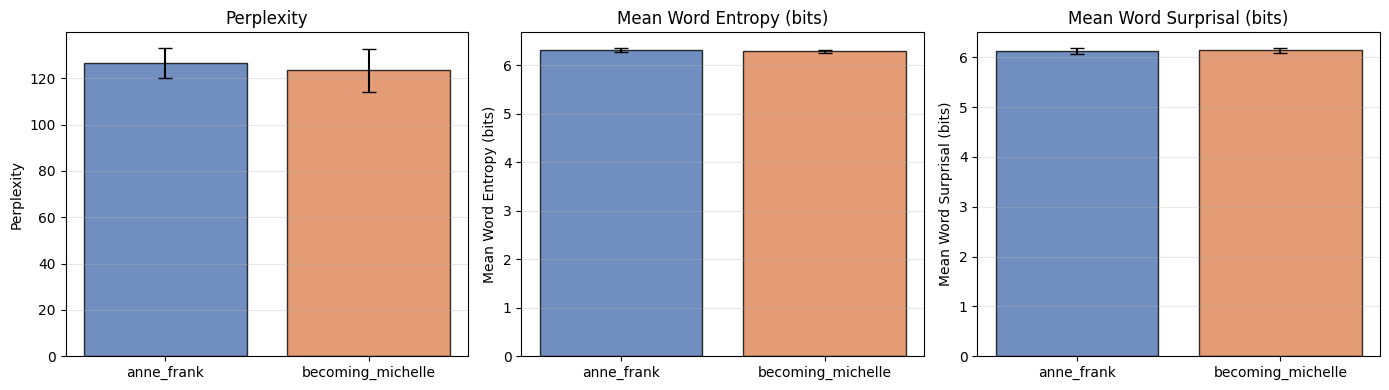

Saved: books_matched_condition_comparison.png


In [13]:
# ============================================================================
# PLOT 1: Bar chart comparing conditions
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

for ax, metric, label in zip(axes, metrics_to_compare,
                              ['Perplexity', 'Mean Word Entropy (bits)', 'Mean Word Surprisal (bits)']):
    grouped = results_df.groupby('condition')[metric]
    means = grouped.mean()
    sems = grouped.sem()

    colors = [condition_colors.get(c, 'gray') for c in means.index]
    bars = ax.bar(means.index, means.values, yerr=sems.values,
                  capsize=5, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('books_matched_condition_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: books_matched_condition_comparison.png')


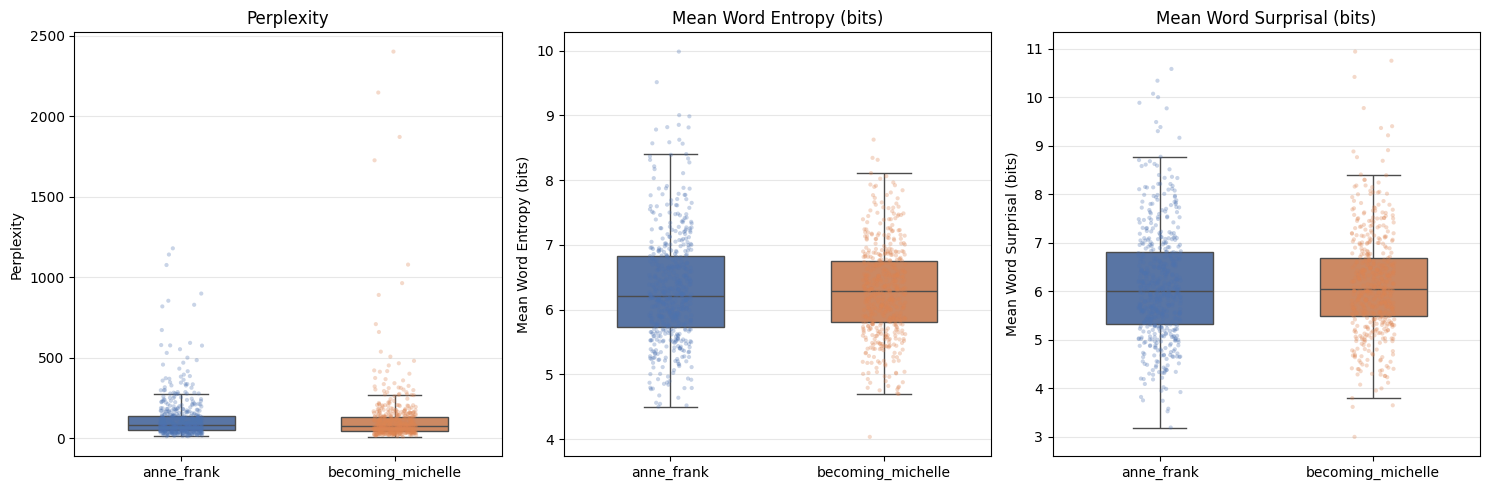

Saved: books_matched_distribution_comparison.png


In [14]:
# ============================================================================
# PLOT 2: Distribution comparison (box + strip plot)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}
palette = [condition_colors[c] for c in ['anne_frank', 'becoming_michelle']]

for ax, metric, label in zip(axes, metrics_to_compare,
                              ['Perplexity', 'Mean Word Entropy (bits)', 'Mean Word Surprisal (bits)']):
    sns.boxplot(data=results_df, x='condition', y=metric, ax=ax,
                palette=palette, width=0.5, showfliers=False,
                order=['anne_frank', 'becoming_michelle'])
    sns.stripplot(data=results_df, x='condition', y=metric, ax=ax,
                  palette=palette, alpha=0.3, size=3, jitter=True,
                  order=['anne_frank', 'becoming_michelle'])
    ax.set_ylabel(label)
    ax.set_xlabel('')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('books_matched_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: books_matched_distribution_comparison.png')


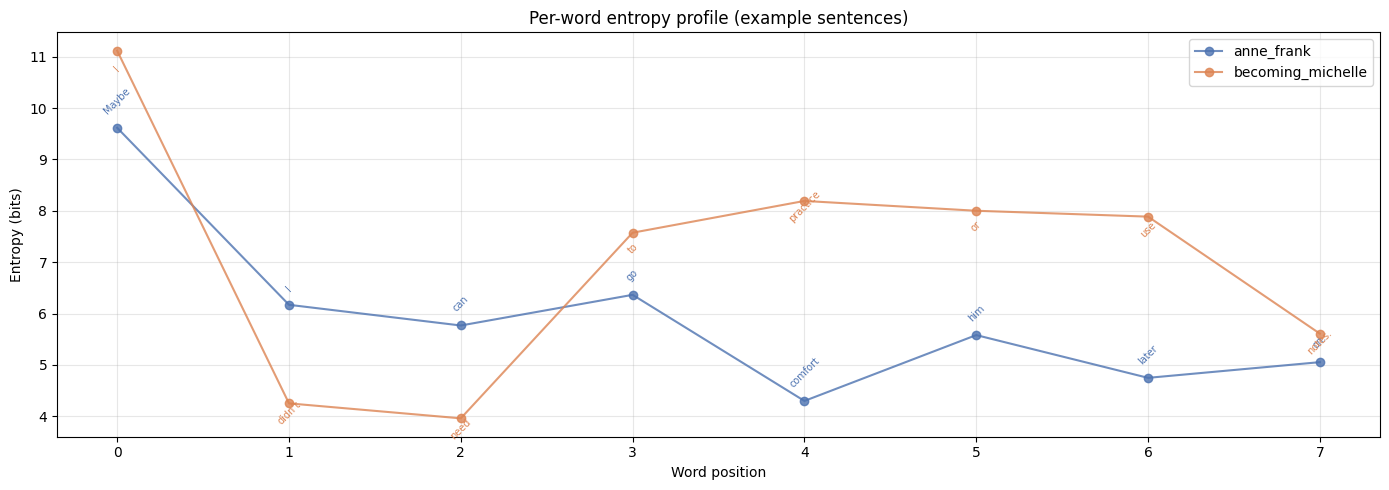

Saved: books_matched_entropy_profile.png


In [15]:
# ============================================================================
# PLOT 3: Per-word entropy profile (example sentence from each condition)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

for condition, color in condition_colors.items():
    # Pick a longer example sentence (at least 8 words) from each condition
    candidates = [item for item in corpus
                  if item['condition'] == condition and len(item['text'].split()) >= 8]
    if not candidates:
        continue
    # Pick the first candidate
    item = candidates[0]
    m = process_text_full_metrics(model, tokenizer, item['text'])

    words = m['words']
    entropies = m['word_entropies']

    positions = range(len(entropies))
    ax.plot(positions, entropies, 'o-', color=color, label=condition, alpha=0.8)

    for pos, word, ent in zip(positions, words[:len(entropies)], entropies):
        offset_y = 10 if condition == 'anne_frank' else -15
        ax.annotate(word, (pos, ent), textcoords='offset points',
                   xytext=(0, offset_y),
                   ha='center', fontsize=7, color=color, rotation=45)

ax.set_xlabel('Word position')
ax.set_ylabel('Entropy (bits)')
ax.set_title('Per-word entropy profile (example sentences)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('books_matched_entropy_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: books_matched_entropy_profile.png')


---
## 8. Corpus-Level Context Ablation

For each sentence, pick 3 random word positions (excluding first and last word)
and measure entropy at context sizes [1, 2, 4, 8, 16]. Aggregate per condition.


Context ablation (random positions):   0%|          | 0/1000 [00:00<?, ?it/s]

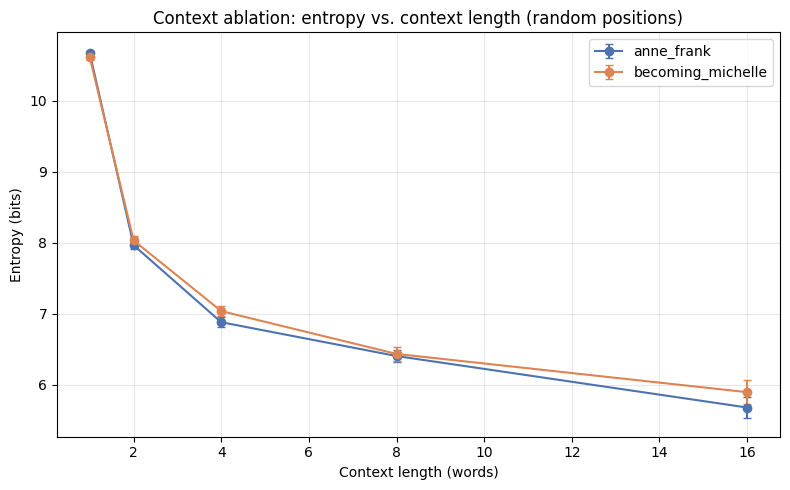

Saved: books_matched_context_ablation.png


In [16]:
# ============================================================================
# CORPUS-LEVEL CONTEXT ABLATION (random positions, entropy only)
# ============================================================================

CONTEXT_SIZES = [1, 2, 4, 8, 16]

all_ablation_results = []

for item in tqdm(corpus, desc='Context ablation (random positions)'):
    text = item['text']
    words = text.split()

    # Need at least 3 words to have eligible positions (excluding first and last)
    if len(words) < 3:
        continue

    # Pick 3 random positions (excluding first and last word)
    eligible = list(range(1, len(words) - 1))
    n_positions = min(3, len(eligible))
    chosen = np.random.choice(eligible, size=n_positions, replace=False)

    for pos in chosen:
        abl_df = context_ablation(
            model, tokenizer, text,
            target_word_index=pos,
            context_sizes=CONTEXT_SIZES
        )

        abl_df['condition'] = item.get('condition', 'unknown')
        abl_df['position'] = pos
        abl_df['target_word'] = words[pos]
        all_ablation_results.append(abl_df)

condition_colors = {'anne_frank': '#4C72B0', 'becoming_michelle': '#DD8452'}

if all_ablation_results:
    ablation_full_df = pd.concat(all_ablation_results, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    for condition, color in condition_colors.items():
        subset = ablation_full_df[ablation_full_df['condition'] == condition]
        if len(subset) == 0:
            continue
        means = subset.groupby('k')['entropy'].mean()
        sems = subset.groupby('k')['entropy'].sem()

        ax.errorbar(means.index, means.values, yerr=sems.values,
                   fmt='o-', color=color, label=condition, capsize=3)

    ax.set_xlabel('Context length (words)')
    ax.set_ylabel('Entropy (bits)')
    ax.set_title('Context ablation: entropy vs. context length (random positions)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('books_matched_context_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: books_matched_context_ablation.png')
else:
    print('No ablation results collected.')


---
## 9. Save Results

Export your results so you can reload them later without re-running the model.

In [17]:
# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save main results as CSV
results_df.to_csv('books_matched_results.csv', index=False)
print('Saved: books_matched_results.csv')

# Save length-matching report
length_df.to_csv('books_length_matching.csv', index=False)
print('Saved: books_length_matching.csv')

# Save comparison statistics
if len(comp_df) > 0:
    comp_df.to_csv('books_matched_comparisons.csv', index=False)
    print('Saved: books_matched_comparisons.csv')

# Save ablation results
if all_ablation_results:
    ablation_full_df.to_csv('books_matched_ablation.csv', index=False)
    print('Saved: books_matched_ablation.csv')

# Save as JSON for programmatic reloading
results_json = results_df.to_dict(orient='records')
with open('books_matched_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: books_matched_results.json')


Saved: books_matched_results.csv
Saved: books_length_matching.csv
Saved: books_matched_comparisons.csv
Saved: books_matched_ablation.csv
Saved: books_matched_results.json


---
## 10. Summary

This notebook compared GPT-2's predictions on text from two books:
- **Anne Frank** — *The Diary of a Young Girl*
- **Becoming Michelle** — *Becoming* by Michelle Obama

We measured perplexity, word-level entropy, word-level surprisal, and ran context ablation
at random word positions. Statistical comparisons used independent-samples Welch's t-tests
and Mann-Whitney U tests.

All results have been saved as CSV, JSON, and PNG files.
